# Data Understanding and Exploratory Data Analysis (EDA)

This notebook performs initial data exploration for the vehicle insurance fraud detection dataset.

Objectives:
- Understand dataset structure
- Identify missing values and data issues
- Analyse class imbalance
- Generate initial insights


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import os


#Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
#Load dataset
df = pd.read_csv("../data/raw/carclaims.csv")  

#Preview
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,PolicyNumber,RepNumber,Deductible,DriverRating,Days:Policy-Accident,Days:Policy-Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,"more than 69,000",1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,"more than 69,000",2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,"more than 69,000",3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,"20,000 to 29,000",4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,"more than 69,000",5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [4]:
#Shape of dataset
print("Shape:", df.shape)

#Data types
df.info()

#Statistical summary
df.describe()

Shape: (15420, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber     

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [5]:
#Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values:\n", missing)

#Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 Series([], dtype: int64)
Duplicate rows: 0


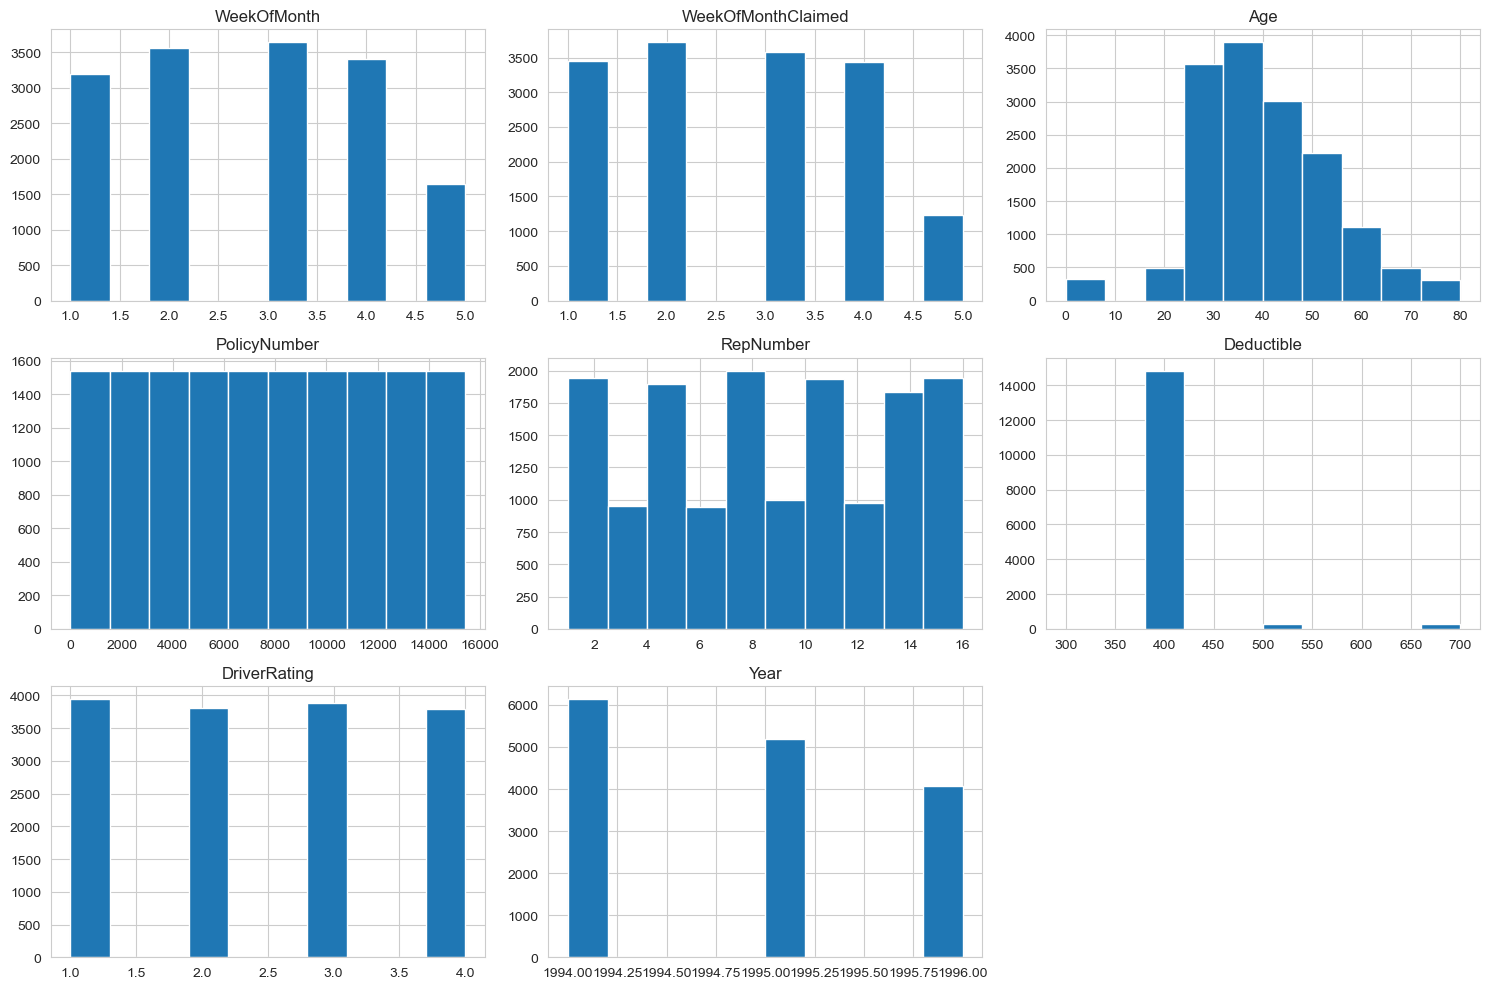

In [6]:
#Numerical features
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

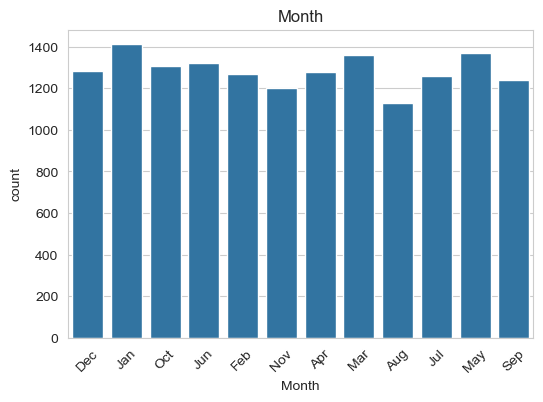

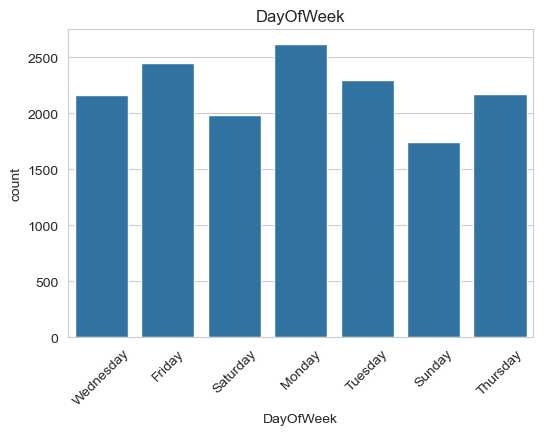

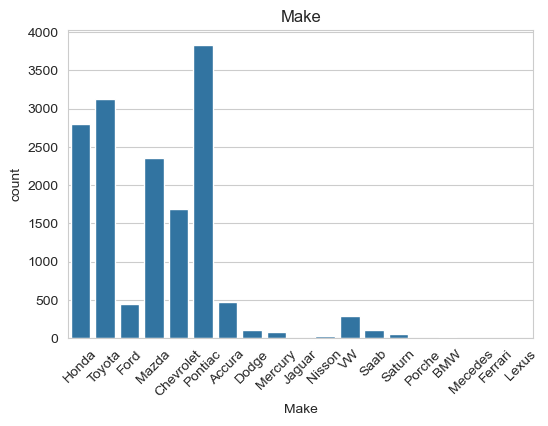

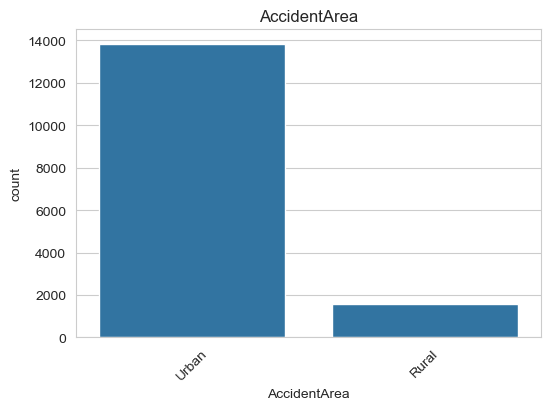

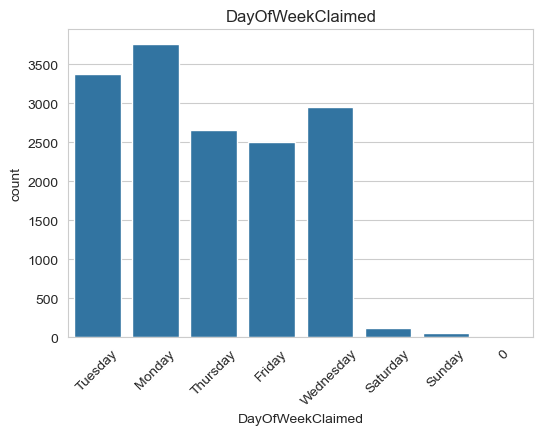

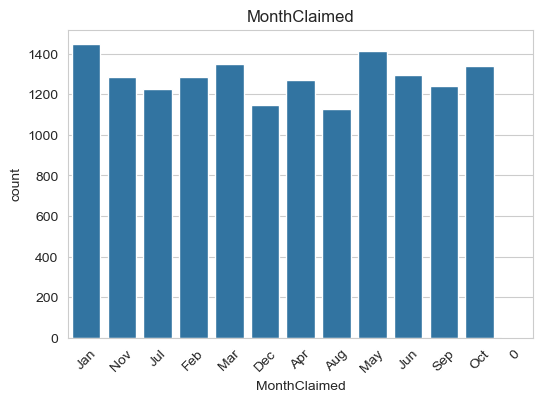

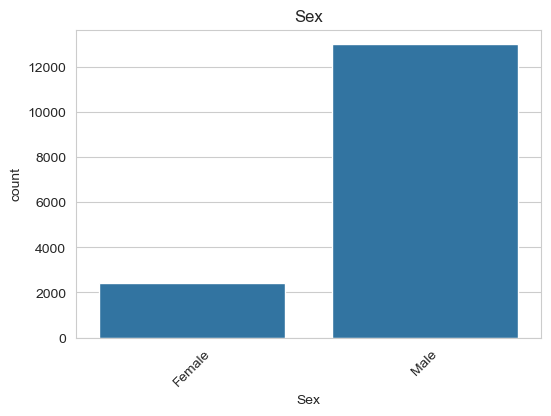

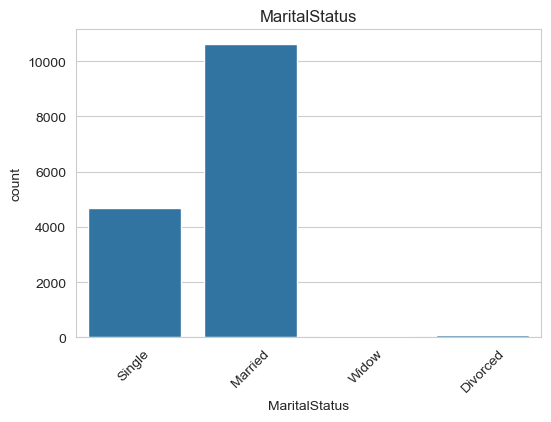

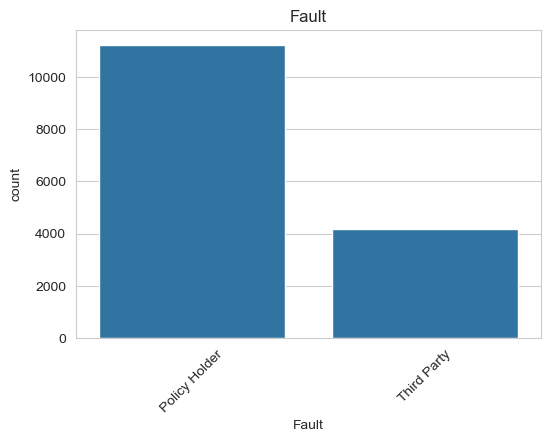

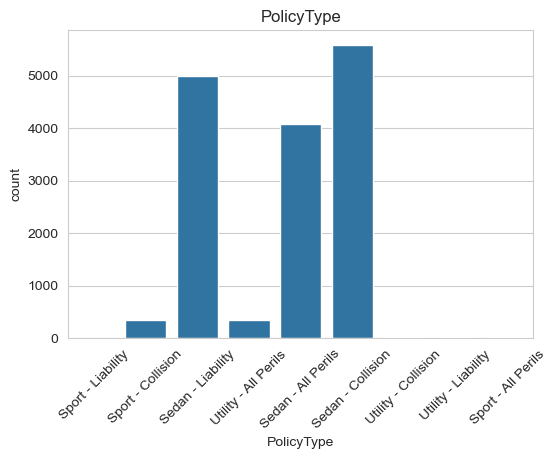

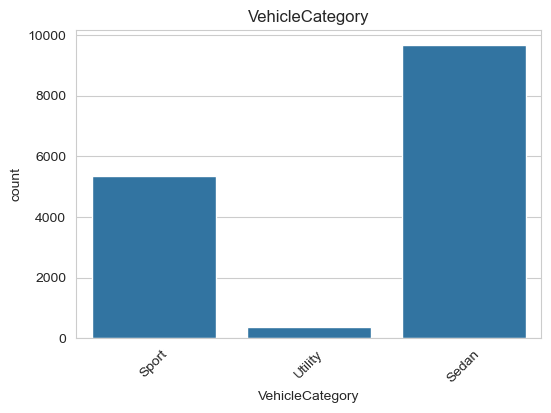

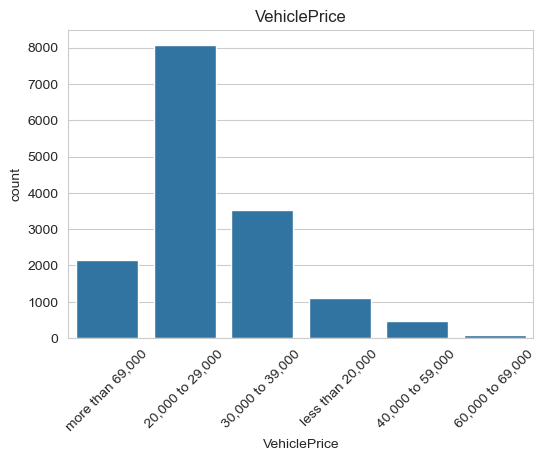

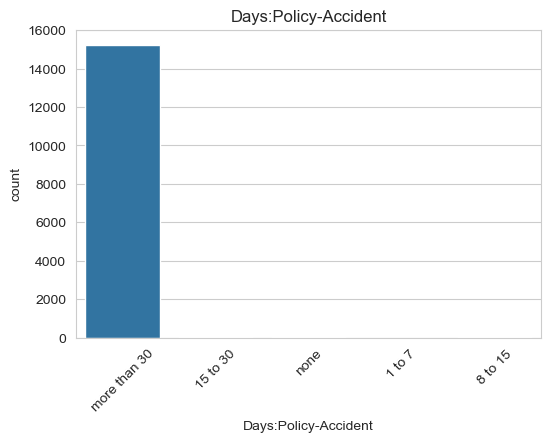

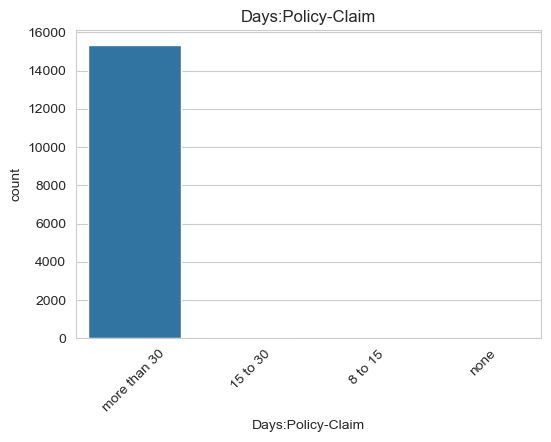

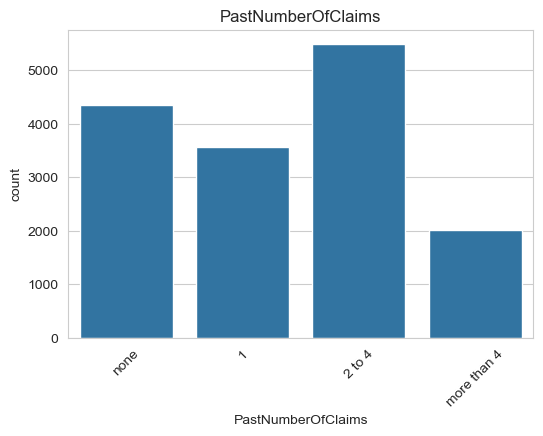

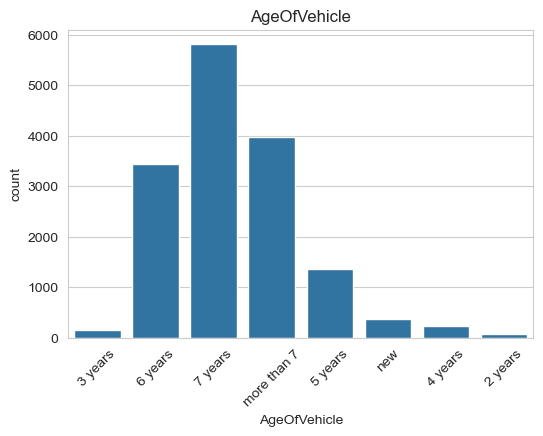

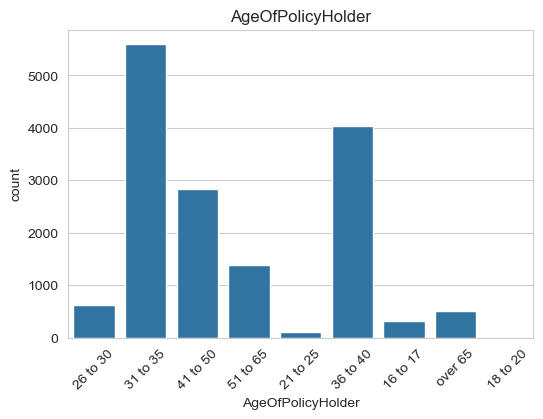

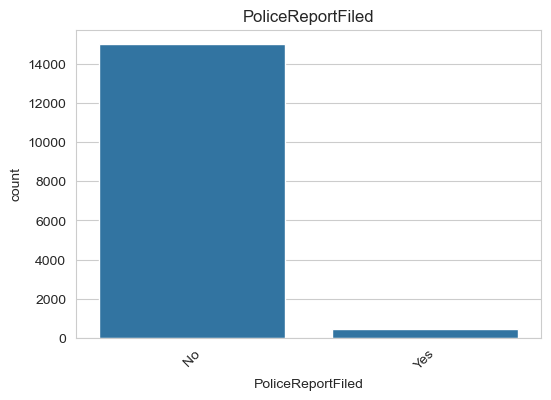

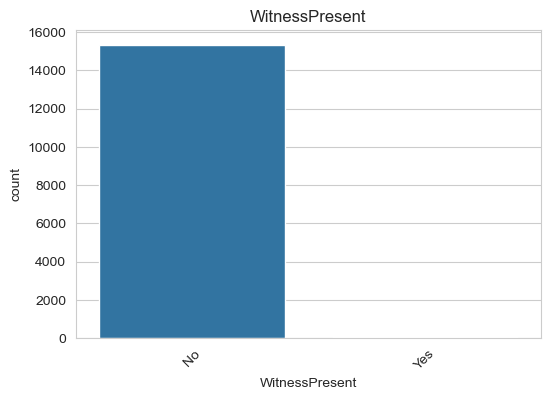

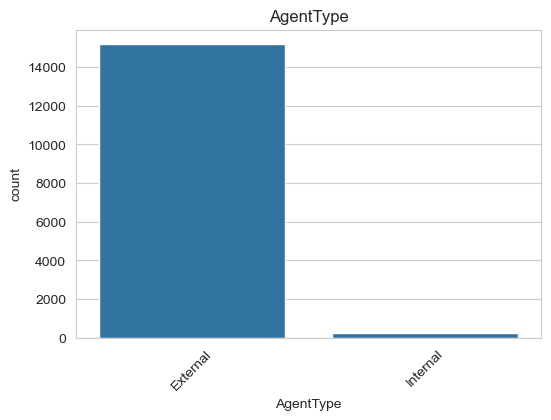

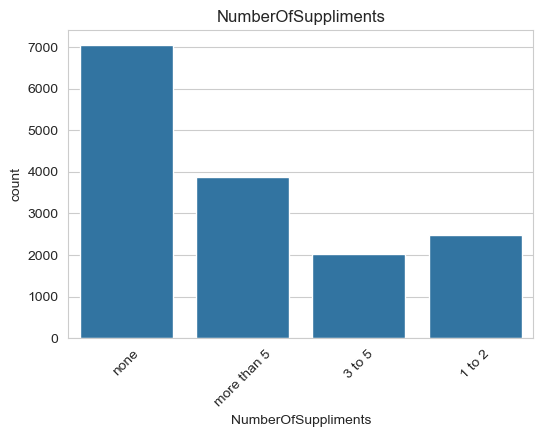

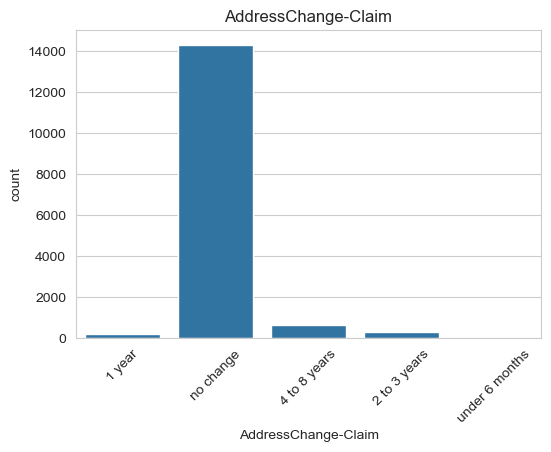

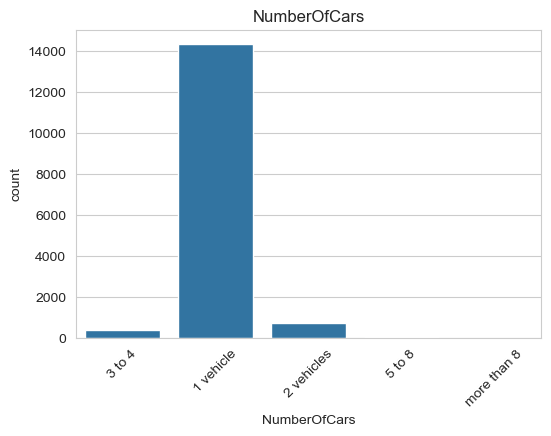

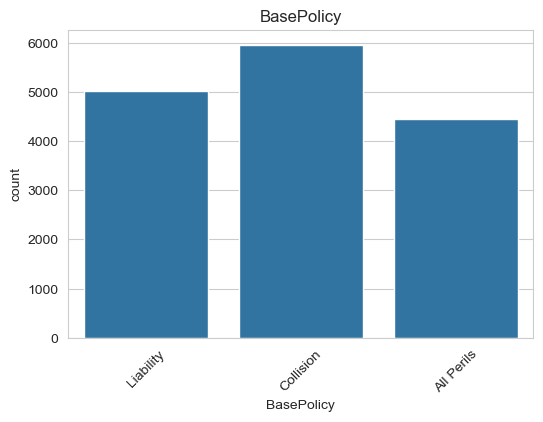

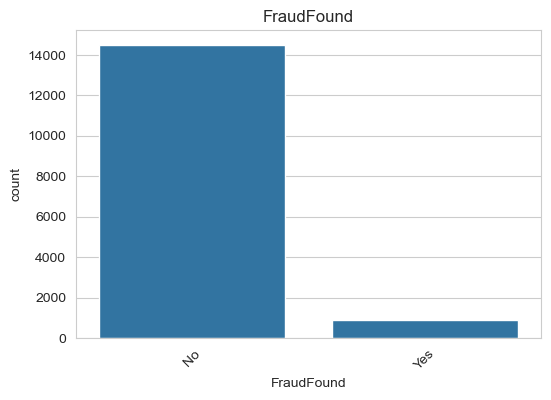

In [7]:
#Categorical features
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

FraudFound
No     14497
Yes      923
Name: count, dtype: int64
FraudFound
No     0.940143
Yes    0.059857
Name: proportion, dtype: float64


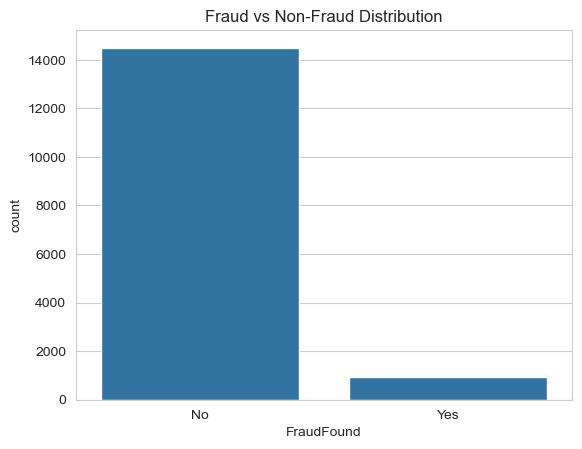

In [8]:
#Class imbalance analysis
target = "FraudFound"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

sns.countplot(data=df, x=target)
plt.title("Fraud vs Non-Fraud Distribution")
plt.savefig("../reports/figures/Fraud_vs_non-fraud_diustribution.png")
plt.show()

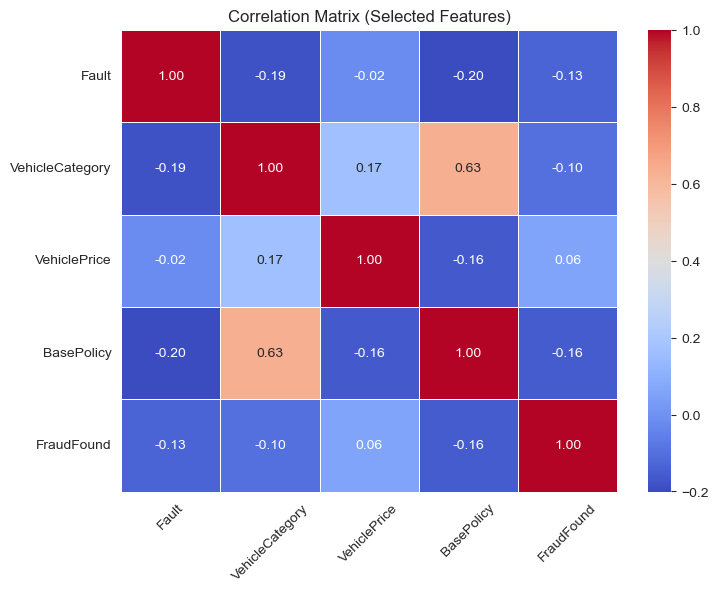

In [9]:
#Correlation matrix

#Select columns of interest
cols_of_interest = [
    "Fault",
    "VehicleCategory",
    "VehiclePrice",
    "BasePolicy",
    "FraudFound"

]

df_corr = df[cols_of_interest].copy()

#Encode categorical variables (for correlation only)
le = LabelEncoder()
for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        df_corr[col] = le.fit_transform(df_corr[col])

#Compute correlation
corr = df_corr.corr()

#Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix (Selected Features)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

#Save figure
plt.savefig("../reports/figures/correlation_selected_features.png", bbox_inches='tight')

plt.show()

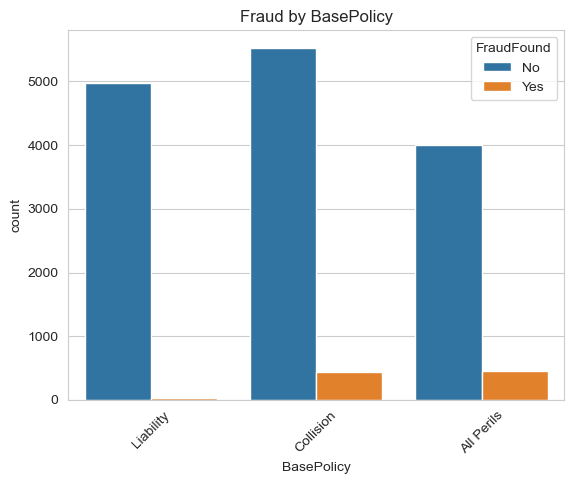

In [10]:
#Fraud vs BasePolicy plot
sns.countplot(data=df, x="BasePolicy", hue="FraudFound")
plt.xticks(rotation=45)
plt.title("Fraud by BasePolicy")

plt.savefig("../reports/figures/fraud_vs_BasePolicy.png", bbox_inches='tight')

plt.show()

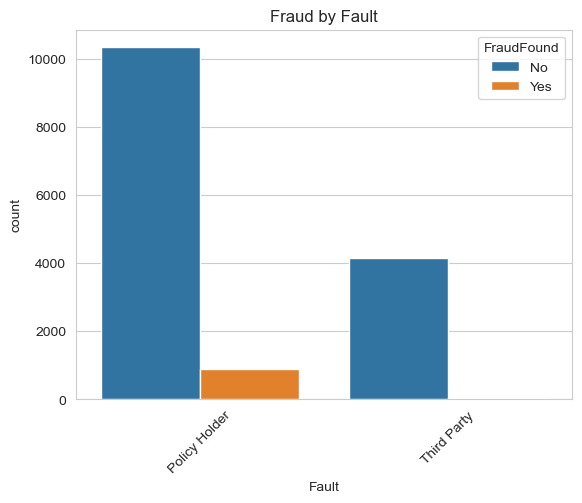

In [11]:
#Fraud vs Fault plot
sns.countplot(data=df, x="Fault", hue="FraudFound")
plt.xticks(rotation=45)
plt.title("Fraud by Fault")

plt.savefig("../reports/figures/fraud_vs_Fault.png", bbox_inches='tight')

plt.show()

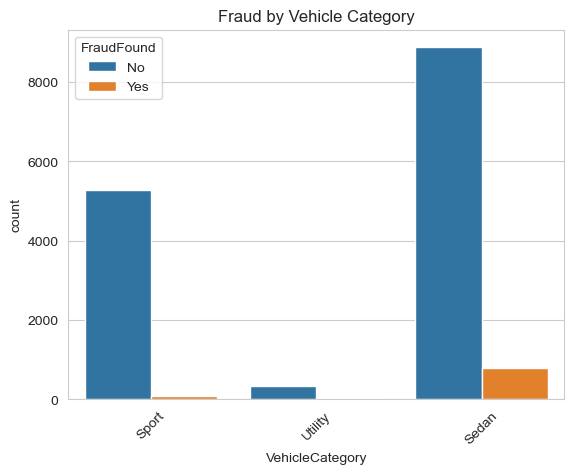

In [12]:
#Fraud vs Vehcile Category plot
sns.countplot(data=df, x="VehicleCategory", hue="FraudFound")
plt.xticks(rotation=45)
plt.title("Fraud by Vehicle Category")

plt.savefig("../reports/figures/fraud_vs_vehicle_category.png", bbox_inches='tight')

plt.show()

# Key Insights

- The dataset contains 15420 records and 33 features.
- There is a significant class imbalance between fraudulent (923) and non-fraudulent (14497) claims.
- The dataset contains no missing values, which simplifies preprocessing.
- Many features are categorical and will require encoding before model training.
- Some features show potential correlation with fraud.
- The dataset contains identifier-like features (e.g., PolicyNumber) which can be removed.
- A focused correlation analysis was conducted on selected features relevant to fraud detection.
- Since several variables are categorical, label encoding was applied for exploratory purposes.

